# Evidências do pipeline de dados: bronze e silver

Este notebook **torna visível** o que acontece nas camadas anteriores à gold. Ele responde,
com saídas visuais, a três perguntas: **como os dados chegaram**, **o que foi transformado**
e **quais tabelas foram geradas**.

> Foco intencional em ingestão, armazenamento e transformação. Não há análise de resultado
> aqui — essa parte fica no `03_gold_analise.ipynb`. O objetivo é evidenciar o pipeline.

As estatísticas vêm de CSVs pequenos gerados pelo `src/pipeline_stats.py`, que reaproveita
as funções reais da transformação (`src/transform_silver.py`). Assim o notabook é leve e
reproduzível, sem recarregar os Parquets pesados de bronze e silver.

## 0. Configuração do ambiente

In [1]:
import os
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

ROOT = Path(os.getcwd())
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
GOLD = ROOT / 'data' / 'gold'
print('Raiz do projeto:', ROOT)

Raiz do projeto: /Users/claudio/Code/me/school/data/project/sus-analytics


## 1. Como os dados chegaram (camada bronze)

A bronze é alimentada por **48 arquivos `.dbc`** do SIH/SUS, um por mês, de janeiro de 2020
a dezembro de 2023. Cada arquivo traz os **113 campos originais** do layout do DATASUS, sem
nenhuma modificação. O gráfico abaixo mostra o volume de registros que chegou em cada mês —
é a "matéria-prima" bruta antes de qualquer limpeza.

Competências (arquivos mensais): 48
Total de registros brutos na bronze: 9,851,942


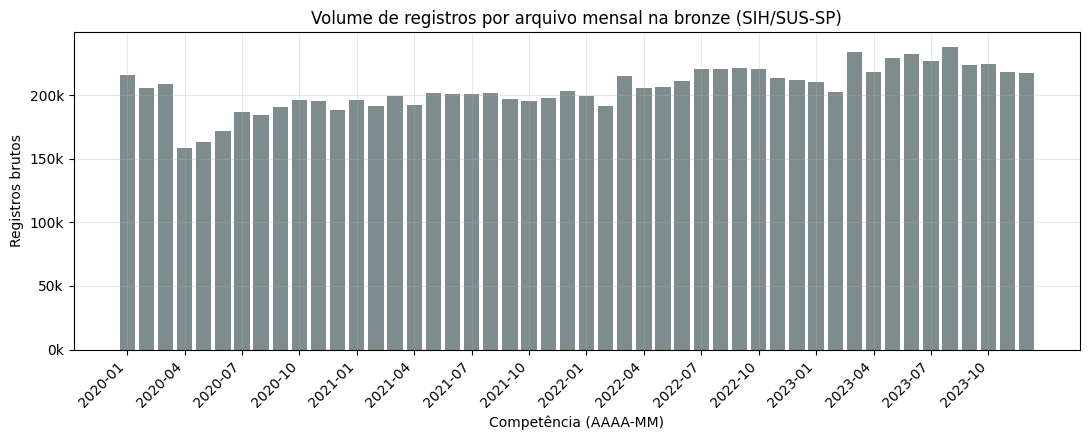

In [2]:
vol = pd.read_csv(GOLD / 'pipeline_volume_mensal.csv')
print(f"Competências (arquivos mensais): {len(vol)}")
print(f"Total de registros brutos na bronze: {vol['registros'].sum():,}")

fig, ax = plt.subplots()
ax.bar(vol['competencia'], vol['registros'], color='#7f8c8d')
ax.set_title('Volume de registros por arquivo mensal na bronze (SIH/SUS-SP)')
ax.set_xlabel('Competência (AAAA-MM)')
ax.set_ylabel('Registros brutos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
passo = 3
ax.set_xticks(range(0, len(vol), passo))
ax.set_xticklabels(vol['competencia'][::passo], rotation=45, ha='right')
plt.tight_layout(); plt.show()

**Leitura.** Os arquivos chegam com volume relativamente estável (em torno de 200 mil
internações por mês), com uma queda perceptível nos meses iniciais de 2020 — quando a
pandemia reduziu as internações eletivas. Esse é o dado **bruto**: ainda contém registros
fora do período, duplicatas e os 113 campos completos.

## 2. O que foi transformado (bronze → silver)

A transformação aplica, em ordem: seleção de 17 campos (de 113), tipagem, remoção de nulos,
remoção de duplicatas e filtro de período (2020–2023). O **funil** abaixo mostra quantas
linhas sobram a cada etapa — é a evidência direta do que a limpeza fez.

etapa,linhas,removidas_na_etapa,pct_do_bronze
Bronze bruto,"9,851,942",0,100.00%
Após tipagem,"9,851,942",0,100.00%
Após remover nulos,"9,851,942",0,100.00%
Após remover duplicatas,"9,804,241","47,701",99.52%
Silver (2020–2023),"9,599,861","204,380",97.44%


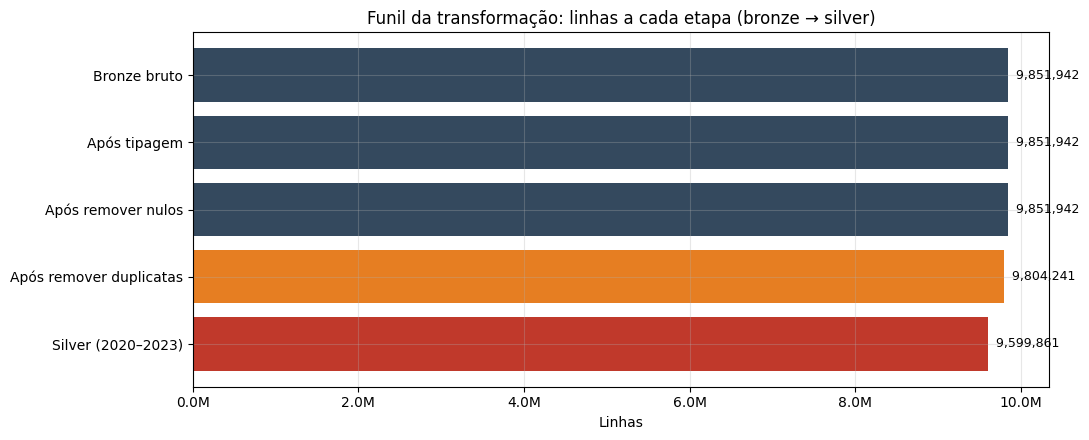

In [3]:
funnel = pd.read_csv(GOLD / 'pipeline_funnel.csv')
display(funnel.style.format({
    'linhas': '{:,.0f}', 'removidas_na_etapa': '{:,.0f}', 'pct_do_bronze': '{:.2f}%'
}).hide(axis='index'))

fig, ax = plt.subplots()
cores = ['#34495e', '#34495e', '#34495e', '#e67e22', '#c0392b']
barras = ax.barh(funnel['etapa'][::-1], funnel['linhas'][::-1], color=cores[::-1])
ax.set_title('Funil da transformação: linhas a cada etapa (bronze → silver)')
ax.set_xlabel('Linhas')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
for b, v in zip(barras, funnel['linhas'][::-1]):
    ax.text(v, b.get_y() + b.get_height()/2, f'  {v:,.0f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

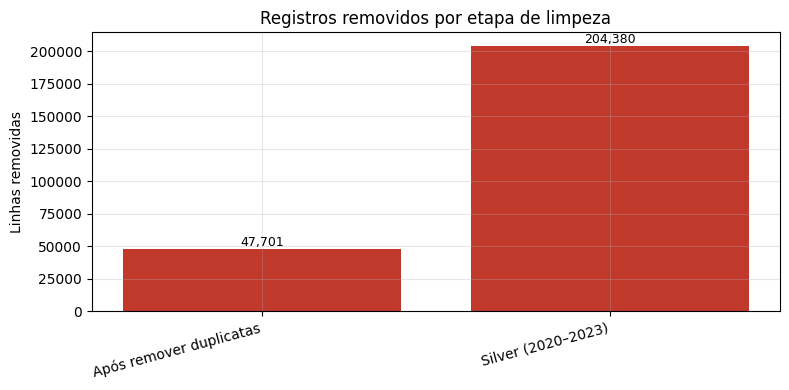

Bronze bruto: 9,851,942 linhas, 113 campos
Silver final: 9,599,861 linhas, 26 colunas (17 selecionados + 9 derivados)
Aproveitamento: 97.44% das linhas


In [4]:
# Quanto cada etapa de limpeza removeu
removidas = funnel[funnel['removidas_na_etapa'] > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(removidas['etapa'], removidas['removidas_na_etapa'], color='#c0392b')
ax.set_title('Registros removidos por etapa de limpeza')
ax.set_ylabel('Linhas removidas')
for i, v in enumerate(removidas['removidas_na_etapa']):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()

total_bronze = funnel.iloc[0]['linhas']
total_silver = funnel.iloc[-1]['linhas']
print(f"Bronze bruto: {total_bronze:,} linhas, 113 campos")
print(f"Silver final: {total_silver:,} linhas, 26 colunas (17 selecionados + 9 derivados)")
print(f"Aproveitamento: {100*total_silver/total_bronze:.2f}% das linhas")

**Leitura.** A transformação preserva a **grande maioria** dos registros: das ~9,85
milhões de linhas brutas, **9,60 milhões** chegam à silver (cerca de 97%). As perdas são
controladas e justificadas: **47.701 duplicatas** exatas e **204.380 registros fora do
período 2020–2023** (datas de internação de anos anteriores que apareciam nos arquivos). A
remoção de nulos não descartou linhas nesta base — os 17 campos selecionados vêm completos.
Além das linhas, a transformação **enxuga a largura**: de **113 campos** para **17
selecionados**, mais **9 colunas derivadas** (`is_covid`, `ano`, `mes`, `ano_mes`,
`faixa_etaria` e as quatro `*_norm`), totalizando 26 colunas na silver.

## 3. Quais tabelas foram geradas (camada gold)

A partir da silver, o `src/build_gold.py` materializa **cinco tabelas agregadas** na camada
gold, cada uma respondendo a um aspecto da pergunta de pesquisa. O gráfico mostra o tamanho
de cada tabela; em seguida, uma amostra de cada uma.

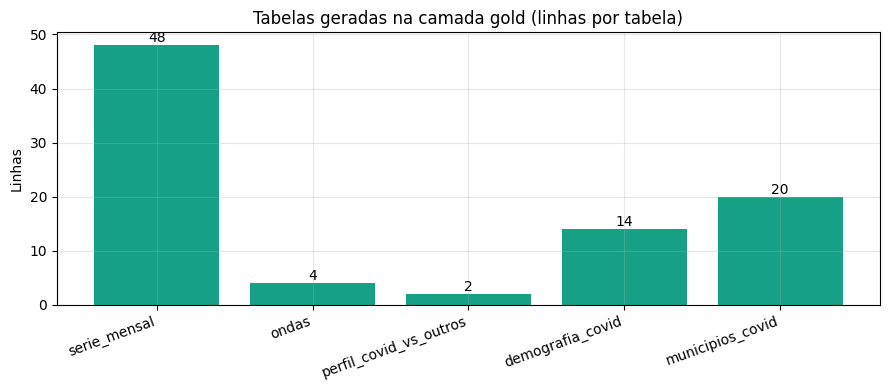

In [5]:
tabelas = ['serie_mensal', 'ondas', 'perfil_covid_vs_outros',
            'demografia_covid', 'municipios_covid']
linhas_por_tabela = {t: len(pd.read_parquet(GOLD / f'{t}.parquet')) for t in tabelas}

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(linhas_por_tabela.keys(), linhas_por_tabela.values(), color='#16a085')
ax.set_title('Tabelas geradas na camada gold (linhas por tabela)')
ax.set_ylabel('Linhas')
for i, v in enumerate(linhas_por_tabela.values()):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

In [6]:
for t in tabelas:
    df = pd.read_parquet(GOLD / f'{t}.parquet')
    print(f'\n=== gold/{t} ({df.shape[0]} linhas x {df.shape[1]} colunas) ===')
    display(df.head(3))


=== gold/serie_mensal (48 linhas x 10 colunas) ===


,ano_mes,internacoes_total,internacoes_covid,internacoes_outros,obitos_total,obitos_covid,obitos_outros,taxa_obito_total,taxa_obito_covid,taxa_obito_outros
0,2020-01-01,217439,0,217439,10695,0,10695,4.92,NaN,4.92
1,2020-02-01,199806,4,199802,9687,2,9685,4.85,50.00,4.85
2,2020-03-01,194919,364,194555,10892,124,10768,5.59,34.07,5.53



=== gold/ondas (4 linhas x 8 colunas) ===


,onda,internacoes_covid,obitos_covid,taxa_obito_covid,dias_perm_medio,pct_com_uti,idade_media,val_medio_aih
0,Onda 1 (original),101195,22212,21.95,8.88,29.50,59.18,5491.46
1,Onda 2 (Gama),268482,63281,23.57,8.85,31.37,56.22,6685.91
2,Onda 3 (Ômicron),29589,7089,23.96,8.99,30.92,62.43,5825.54



=== gold/perfil_covid_vs_outros (2 linhas x 8 colunas) ===


,grupo,internacoes,obitos,taxa_obito,dias_perm_medio,pct_com_uti,idade_media,val_medio_aih
0,Outros motivos,9188589,505529,5.5,5.06,9.69,43.5,1578.23
1,COVID (B342),411272,94571,22.99,8.86,30.45,57.57,6181.92



=== gold/demografia_covid (14 linhas x 5 colunas) ===


,sexo,faixa_etaria,internacoes,obitos,taxa_obito
0,Feminino,0-4,2625,47,1.79
1,Feminino,15-29,8440,617,7.31
2,Feminino,30-44,27324,3186,11.66



=== gold/municipios_covid (20 linhas x 4 colunas) ===


,munic_mov_ibge,internacoes_covid,obitos_covid,taxa_obito_covid
0,355030,94790,22398,23.63
1,354780,13142,2468,18.78
2,350950,12803,2871,22.42


**Leitura.** As cinco tabelas gold são pequenas e prontas para consumo: `serie_mensal`
(48 meses), `ondas` (4 janelas), `perfil_covid_vs_outros` (2 grupos), `demografia_covid`
(14 combinações de sexo e faixa) e `municipios_covid` (top 20). Por serem leves, ficam
versionadas no repositório (CSV e Parquet em `data/gold/`), servindo de evidência direta
do que o pipeline produziu — sem precisar reprocessar os dados brutos.

## Resumo do pipeline evidenciado

| Camada | O que é | Volume | Artefato |
| ------ | ------- | ------ | -------- |
| **Bronze** | Dado bruto, 113 campos, 48 arquivos `.dbc` | ~9,85 M linhas | `data/bronze/sihsus_sp_raw.parquet` |
| **Silver** | Limpo, tipado, 26 colunas | ~9,60 M linhas | `data/silver/sihsus_sp.parquet` |
| **Gold** | 5 tabelas agregadas | 88 linhas no total | `data/gold/*.parquet` e `*.csv` |

Cada etapa tem um script dedicado (`ingest_bronze.py`, `transform_silver.py`, `build_gold.py`),
e este notebook mostra, com números e gráficos, o que cada uma fez aos dados.